In [ ]:
!pip install torch torchvision nltk pillow matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import nltk
import numpy as np
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
def preprocess_text(text):

    text = text.lower()

    tokens = word_tokenize(text)

    return tokens

In [ ]:
class Vocabulary:

    def __init__(self):

        self.word2idx = {"<UNK>":0}
        self.idx2word = {0:"<UNK>"}
        self.idx = 1

    def add_word(self, word):

        if word not in self.word2idx:

            self.word2idx[word] = self.idx
            self.idx2word[self.idx] = word

            self.idx += 1

    def build_vocab(self, sentences):

        for sentence in sentences:

            tokens = preprocess_text(sentence)

            for word in tokens:

                self.add_word(word)

In [ ]:
sentences = [
"A red bird",
"A blue flower",
"A green tree"
]

vocab = Vocabulary()

vocab.build_vocab(sentences)

print(vocab.word2idx)

{'<UNK>': 0, 'a': 1, 'red': 2, 'bird': 3, 'blue': 4, 'flower': 5, 'green': 6, 'tree': 7}


# New Section

In [ ]:
embedding = torch.nn.Embedding(len(vocab.word2idx),100).to(device)

In [ ]:
def text_to_embedding(text):

    tokens = preprocess_text(text)

    indices = [
        vocab.word2idx.get(word, vocab.word2idx["<UNK>"])
        for word in tokens
    ]

    indices = torch.tensor(indices).long().to(device)

    embed = embedding(indices)

    embed = torch.mean(embed,dim=0)

    return embed

In [ ]:
class Generator(nn.Module):

    def __init__(self,noise_dim,embed_dim):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(noise_dim+embed_dim,256),
            nn.ReLU(True),

            nn.Linear(256,512),
            nn.ReLU(True),

            nn.Linear(512,1024),
            nn.ReLU(True),

            nn.Linear(1024,784),
            nn.Tanh()
        )

    def forward(self,noise,text_embed):

        x = torch.cat((noise,text_embed),dim=1)

        img = self.model(x)

        return img.view(-1,1,28,28)

In [ ]:
class Discriminator(nn.Module):

    def __init__(self,embed_dim):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(784+embed_dim,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,img,text_embed):

        img = img.view(-1,784)

        x = torch.cat((img,text_embed),dim=1)

        validity = self.model(x)

        return validity

In [ ]:
noise_dim = 100
embed_dim = 100

generator = Generator(noise_dim,embed_dim).to(device)

discriminator = Discriminator(embed_dim).to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(),lr=0.0002)

optimizer_D = optim.Adam(discriminator.parameters(),lr=0.0002)

In [ ]:
text_embed = text_to_embedding(text).unsqueeze(0)

In [ ]:
text_embed = text_to_embedding(text).unsqueeze(0).detach()

In [ ]:
epochs = 10
batch_size = 32

for epoch in range(epochs):

    text = "A red bird"

    text_embed = text_to_embedding(text).unsqueeze(0).detach()
    text_embed = text_embed.repeat(batch_size,1)

    real_labels = torch.ones(batch_size,1).to(device)
    fake_labels = torch.zeros(batch_size,1).to(device)

    # --------------------
    # Train Generator
    # --------------------

    optimizer_G.zero_grad()

    noise = torch.randn(batch_size,noise_dim).to(device)

    fake_images = generator(noise,text_embed)

    validity = discriminator(fake_images,text_embed)

    g_loss = criterion(validity,real_labels)

    g_loss.backward()
    optimizer_G.step()

    # --------------------
    # Train Discriminator
    # --------------------

    optimizer_D.zero_grad()

    real_images = torch.randn(batch_size,1,28,28).to(device)

    real_validity = discriminator(real_images,text_embed)

    d_real_loss = criterion(real_validity,real_labels)

    noise = torch.randn(batch_size,noise_dim).to(device)

    fake_images = generator(noise,text_embed).detach()

    fake_validity = discriminator(fake_images,text_embed)

    d_fake_loss = criterion(fake_validity,fake_labels)

    d_loss = (d_real_loss + d_fake_loss)/2

    d_loss.backward()
    optimizer_D.step()

    print(f"Epoch {epoch} | D Loss {d_loss.item()} | G Loss {g_loss.item()}")

Epoch 0 | D Loss 0.7246255874633789 | G Loss 0.6998158693313599
Epoch 1 | D Loss 0.7067635655403137 | G Loss 0.6928505301475525
Epoch 2 | D Loss 0.6864726543426514 | G Loss 0.6845840811729431
Epoch 3 | D Loss 0.6708353161811829 | G Loss 0.6784707307815552
Epoch 4 | D Loss 0.6578153371810913 | G Loss 0.6705370545387268
Epoch 5 | D Loss 0.6485864520072937 | G Loss 0.664347767829895
Epoch 6 | D Loss 0.6408353447914124 | G Loss 0.656308650970459
Epoch 7 | D Loss 0.6301393508911133 | G Loss 0.655634880065918
Epoch 8 | D Loss 0.6132413148880005 | G Loss 0.6539087295532227
Epoch 9 | D Loss 0.6052199602127075 | G Loss 0.6560653448104858


In [ ]:
def generate_image(text):

    noise = torch.randn(1,noise_dim).to(device)

    text_embed = text_to_embedding(text).unsqueeze(0)

    fake_image = generator(noise,text_embed)

    img = fake_image.detach().cpu().squeeze()

    plt.imshow(img,cmap="gray")

    plt.title(text)

    plt.axis("off")

    plt.show()

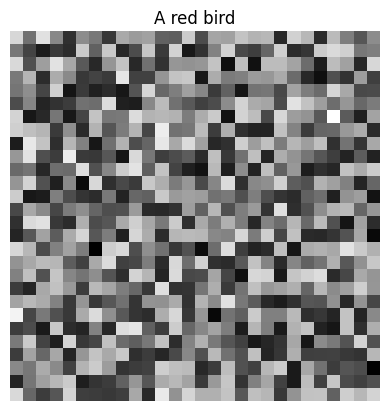

In [ ]:
generate_image("A red bird")